In [ ]:
import tensorflow as tf 
from tensorflow.keras import layers, models

# Parameters 
bach_size = 32
img_height = 180
img_width = 180

data_dir = r"C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages"

# load dataset 
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123, 
    image_size = (180,180), 
    batch_size = 32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
 data_dir, 
    validation_split = 0.2,
    subset = "validation",
    seed = 123, 
    image_size = (180,180), 
    batch_size = 32
)



In [6]:
import os

for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(data_dir, folder)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            # Delete the file if it's not a valid JFIF
            os.remove(fpath)
            print(f"Deleted corrupt image: {fpath}")

Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10019.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10036.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10037.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10070.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10073.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10077.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10117.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages\Cat\10125.jpg
Deleted corrupt image: C:\Users\mohib\Desktop\MachineLea

In [8]:
import tensorflow as tf

data_dir = r"C:\Users\mohib\Desktop\MachineLearning\archive\kagglecatsanddogs_3367a\PetImages"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 23391 files belonging to 2 classes.
Using 18713 files for training.
Found 23391 files belonging to 2 classes.
Using 4678 files for validation.


In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [11]:
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 309s 525ms/step - accuracy: 0.6300 - loss: 0.6783 - val_accuracy: 0.6888 - val_loss: 0.5956
Epoch 2/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 308s 526ms/step - accuracy: 0.7444 - loss: 0.5179 - val_accuracy: 0.7285 - val_loss: 0.5456
Epoch 3/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 307s 525ms/step - accuracy: 0.8336 - loss: 0.3712 - val_accuracy: 0.7450 - val_loss: 0.5792
Epoch 4/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 307s 525ms/step - accuracy: 0.9203 - loss: 0.1953 - val_accuracy: 0.7187 - val_loss: 1.0444
Epoch 5/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 310s 530ms/step - accuracy: 0.9677 - loss: 0.0919 - val_accuracy: 0.7311 - val_loss: 1.1439
Epoch 6/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 311s 531ms/step - accuracy: 0.9827 - loss: 0.0550 - val_accuracy: 0.7294 - val_loss: 1.2936
Epoch 7/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 313s 534ms/step - accuracy: 0.9876 - loss: 0.0436 - val_accuracy: 0.7285 - val_loss: 1.4313
Epoch 8/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 311s 532ms/step - accuracy: 0.9890 -

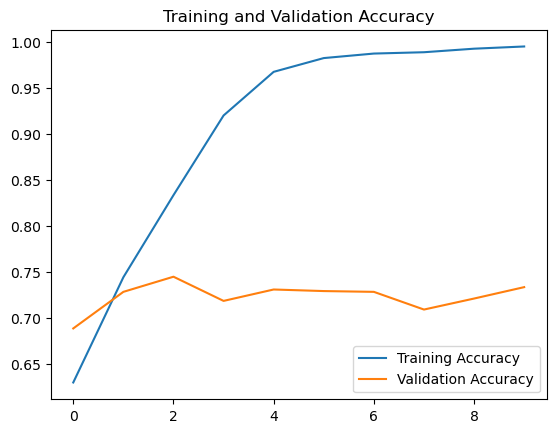

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(epochs)

plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

In [14]:
import numpy as np

img = tf.keras.utils.load_img("cat.jpg", target_size=(180, 180))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) 

predictions = model.predict(img_array)
score = predictions[0]

if score > 0.5:
    print(f"This is {(100 * score[0]):.2f}% likely a Dog.")
else:
    print(f"This is {(100 * (1 - score[0])):.2f}% likely a Cat.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
This is 99.97% likely a Cat.
